# CREMA-D Training — YOLO11 (Ultralytics)

Trains an emotion classifier on the CREMA-D mel-spectrogram PNGs using the
**Ultralytics YOLO11 classification** model.

**How to use this notebook:**
- Run cells from top to bottom.
- Edit the **Configuration** cell to set the model variant, image size, batch
  size, learning rate, and number of epochs.
- Ultralytics owns its own training loop — there is no hand-written PyTorch
  loop here (unlike `training_template.ipynb`).

**Prerequisites — this notebook assumes you have a local env in conda ready with Ultralytics & Yolo. The rest of the steps will be from my local env:**

```bash
source ~/miniconda3/bin/activate && conda activate ultra
# one-time: the ultra env ships ultralytics + torch but not Jupyter
pip install jupyter ipykernel
jupyter notebook        # then open this file
```

- `data/` folder present in this directory (see `README.md` for the download link).
- Run this notebook from the `training/` directory.

## 0) Environment & dependencies

In [32]:
# The `ultra` conda env already provides ultralytics + torch (CUDA build).
# This cell only *verifies* that, and pip-installs into the active env
# anything that happens to be missing — it will not reinstall the heavy stack.
import importlib, subprocess, sys

REQUIRED = {
    "ultralytics": "ultralytics",
    "torch":       "torch",
    "pandas":      "pandas",      # ultralytics writes results.csv
    "matplotlib":  "matplotlib",
    "scikit-learn":"sklearn",
}

missing = [pkg for pkg, mod in REQUIRED.items()
           if importlib.util.find_spec(mod) is None]
if missing:
    print(f"Installing missing packages: {missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
else:
    print("All required packages already present.")

import torch, ultralytics
print(f"python      {sys.executable}")
print(f"ultralytics {ultralytics.__version__}")
print(f"torch       {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

All required packages already present.
python      /home/velu/miniconda3/envs/ultra/bin/python
ultralytics 8.3.162
torch       2.7.1+cu128
CUDA available: True


## 1) Imports

In [33]:
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Image, display
from PIL import Image as PILImage
from sklearn.metrics import classification_report, confusion_matrix
from ultralytics import YOLO

## 2) Configuration

Edit the values in this cell to suit your experiment.

In [37]:
# ── Paths ───────────────────────────────────────────────
# Assumes this notebook is run from the training/ directory.
# If not, set DATA_DIR manually, e.g.: DATA_DIR = Path("/abs/path/to/data")
DATA_DIR  = Path.cwd() / "data"
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR  = DATA_DIR / "test"

# Ultralytics classification expects a dataset root with train/ and val/
# subdirectories. The CREMA-D data we have is train/ + test/, so we build a
# lightweight symlinked dataset (see section 4): val/ points at data/test.
YOLO_DATASET_DIR = Path.cwd() / "yolo_dataset"   # local only

# ── Model ──────────────────────────────────────────────
# Classification checkpoints: yolo11{n,s,m,l,x}-cls.pt  (weights auto-download).
MODEL = "yolo11s-cls.pt"

# ── Image settings ──────────────────────────────────────
# Spectrograms are 640×640 PNGs
IMAGE_SIZE = 640

# ── Training hyperparameters ────────────────────────────────
BATCH_SIZE    = 32
NUM_EPOCHS    = 100
LEARNING_RATE = 1e-3   # passed to ultralytics as lr0
RUN_NAME      = "yolo11s_cremad"

# ── Dataset ────────────────────────────────────────────
CLASS_NAMES = ["ANG", "DIS", "FEA", "HAP", "NEU", "SAD"]
NUM_CLASSES = len(CLASS_NAMES)

# ── Device ──────────────────────────────────────────
# Ultralytics device: 0 = first CUDA GPU, 'cpu' otherwise.
DEVICE = 0 if torch.cuda.is_available() else "cpu"

# ── Output ──────────────────────────────────────────
MODEL_SAVE_PATH = Path("model_yolo.pt")

print(f"Data dir : {DATA_DIR}")
print(f"Model    : {MODEL}")
print(f"Device   : {DEVICE!r}")
print(f"Classes  : {CLASS_NAMES}")

Data dir : /home/velu/Documents/ISY-PM-2026-AIS07PT-Group31_PLACEHOLDER/SystemCode/data/training/data
Model    : yolo11s-cls.pt
Device   : 0
Classes  : ['ANG', 'DIS', 'FEA', 'HAP', 'NEU', 'SAD']


## 3) Verify data structure

In [38]:
assert DATA_DIR.exists(), (
    f"data/ not found at {DATA_DIR}.\n"
    "Download it from the shared drive link in training/README.md and extract it here."
)

print(f"{'Split':<8} {'Emotion':<8} {'PNGs':>6} {'WAVs':>6}")
print("-" * 34)
total_png = total_wav = 0
for split, split_dir in [("train", TRAIN_DIR), ("test", TEST_DIR)]:
    for cls in CLASS_NAMES:
        cls_dir = split_dir / cls
        assert cls_dir.exists(), f"Missing expected directory: {cls_dir}"
        n_png = len(list(cls_dir.glob("*.png")))
        n_wav = len(list(cls_dir.glob("*.wav")))
        total_png += n_png
        total_wav += n_wav
        print(f"{split:<8} {cls:<8} {n_png:>6} {n_wav:>6}")

print("-" * 34)
print(f"{'TOTAL':<17} {total_png:>6} {total_wav:>6}")
print("\nData structure OK.")

Split    Emotion    PNGs   WAVs
----------------------------------
train    ANG        1006   1006
train    DIS        1006   1006
train    FEA        1006   1006
train    HAP        1006   1006
train    NEU         860    860
train    SAD        1006   1006
test     ANG         265    265
test     DIS         265    265
test     FEA         265    265
test     HAP         265    265
test     NEU         227    227
test     SAD         265    265
----------------------------------
TOTAL               7442   7442

Data structure OK.


## 4) Build the YOLO classification dataset

Ultralytics image classification expects a dataset root containing `train/`
and `val/`, each with one subdirectory per class. The CREMA-D dataset is
`train/` + `test/`, so we build `yolo_dataset/` using **symlinks** —
`train/ → data/train`, `val/ → data/test`. No files are copied.

> `yolo_dataset/` is local-only and regenerated each run — do not commit it.

In [39]:
if YOLO_DATASET_DIR.exists() or YOLO_DATASET_DIR.is_symlink():
    shutil.rmtree(YOLO_DATASET_DIR)
YOLO_DATASET_DIR.mkdir(parents=True)

(YOLO_DATASET_DIR / "train").symlink_to(TRAIN_DIR.resolve(), target_is_directory=True)
(YOLO_DATASET_DIR / "val").symlink_to(TEST_DIR.resolve(),  target_is_directory=True)

for split in ("train", "val"):
    link = YOLO_DATASET_DIR / split
    n = sum(len(list((link / c).glob('*.png'))) for c in CLASS_NAMES)
    print(f"{split:<5} -> {link.resolve()}  ({n} PNGs across {NUM_CLASSES} classes)")

train -> /home/velu/Documents/ISY-PM-2026-AIS07PT-Group31_PLACEHOLDER/SystemCode/data/training/data/train  (5890 PNGs across 6 classes)
val   -> /home/velu/Documents/ISY-PM-2026-AIS07PT-Group31_PLACEHOLDER/SystemCode/data/training/data/test  (1552 PNGs across 6 classes)


### Visualise a sample

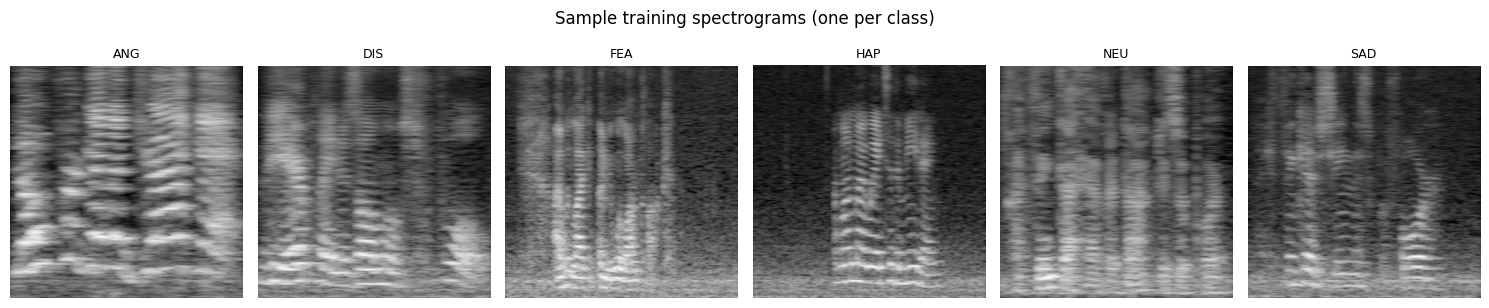

In [40]:
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(2.5 * NUM_CLASSES, 3))
for ax, cls in zip(axes, CLASS_NAMES):
    sample = next((TRAIN_DIR / cls).glob("*.png"))
    ax.imshow(PILImage.open(sample), cmap="gray")
    ax.set_title(cls, fontsize=9)
    ax.axis("off")
plt.suptitle("Sample training spectrograms (one per class)", y=1.02)
plt.tight_layout()
plt.show()

## 5) Model

Loads a YOLO11 classification checkpoint pretrained on ImageNet. The
classification head is sized automatically from the dataset's class count
the first time `train()` runs.

In [41]:
model = YOLO(MODEL)
print(f"Loaded {MODEL}")
model.info()

Loaded yolo11s-cls.pt
YOLO11s-cls summary: 86 layers, 6,724,008 parameters, 0 gradients, 13.2 GFLOPs


(86, 6724008, 0, 13.158604799999999)

## 6) Training

Ultralytics runs its own training loop, augmentation, checkpointing and
logging. Outputs are written to `runs/classify/<RUN_NAME>/`.

In [42]:
results = model.train(
    data=str(YOLO_DATASET_DIR),
    epochs=NUM_EPOCHS,
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    lr0=LEARNING_RATE,
    device=DEVICE,
    project="runs/classify",
    name=RUN_NAME,
    exist_ok=True,
    verbose=True,
)

RUN_DIR = Path(model.trainer.save_dir)
print(f"\nRun directory: {RUN_DIR.resolve()}")

New https://pypi.org/project/ultralytics/8.4.51 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.162 🚀 Python-3.13.5 torch-2.7.1+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Ti, 15840MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/velu/Documents/ISY-PM-2026-AIS07PT-Group31_PLACEHOLDER/SystemCode/data/training/yolo_dataset, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s-cls.pt, momentum=0.937,

train: Scanning /home/velu/Documents/ISY-PM-2026-AIS07PT-Group31_PLACEHOLDER/SystemCode/data/training/yolo_dataset/train... 5890 images, 0 corrupt: 100%|██████████| 5890/5890 [00:01<00:00, 5363.32it/s]


train: New cache created: /home/velu/Documents/ISY-PM-2026-AIS07PT-Group31_PLACEHOLDER/SystemCode/data/training/yolo_dataset/train.cache
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2867.4±1862.3 MB/s, size: 192.5 KB)


val: Scanning /home/velu/Documents/ISY-PM-2026-AIS07PT-Group31_PLACEHOLDER/SystemCode/data/training/yolo_dataset/val... 1552 images, 0 corrupt: 100%|██████████| 1552/1552 [00:00<00:00, 3319.80it/s]

val: New cache created: /home/velu/Documents/ISY-PM-2026-AIS07PT-Group31_PLACEHOLDER/SystemCode/data/training/yolo_dataset/val.cache


...

    100/100       6.6G     0.2074          2        640: 100%|██████████| 185/185 [00:29<00:00,  6.33it/s]
               classes   top1_acc   top5_acc: 100%|██████████| 25/25 [00:02<00:00,  8.56it/s]

                   all      0.603      0.981



100 epochs completed in 0.903 hours.
Optimizer stripped from runs/classify/yolo11s_cremad/weights/last.pt, 11.0MB
Optimizer stripped from runs/classify/yolo11s_cremad/weights/best.pt, 11.0MB

Validating runs/classify/yolo11s_cremad/weights/best.pt...
Ultralytics 8.3.162 🚀 Python-3.13.5 torch-2.7.1+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Ti, 15840MiB)
YOLO11s-cls summary (fused): 47 layers, 5,441,814 parameters, 0 gradients, 12.0 GFLOPs
train: /home/velu/Documents/ISY-PM-2026-AIS07PT-Group31_PLACEHOLDER/SystemCode/data/training/yolo_dataset/train... found 5890 images in 6 classes ✅ 
val: /home/velu/Documents/ISY-PM-2026-AIS07PT-Group31_PLACEHOLDER/SystemCode/data/training/yolo_dataset/val... found 1552 images in 6 classes ✅ 
test: None...


               classes   top1_acc   top5_acc: 100%|██████████| 25/25 [00:02<00:00,  8.44it/s]


                   all      0.607      0.984
Speed: 0.4ms preprocess, 1.3ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs/classify/yolo11s_cremad

Run directory: /home/velu/Documents/ISY-PM-2026-AIS07PT-Group31_PLACEHOLDER/SystemCode/data/training/runs/classify/yolo11s_cremad


### Training curves

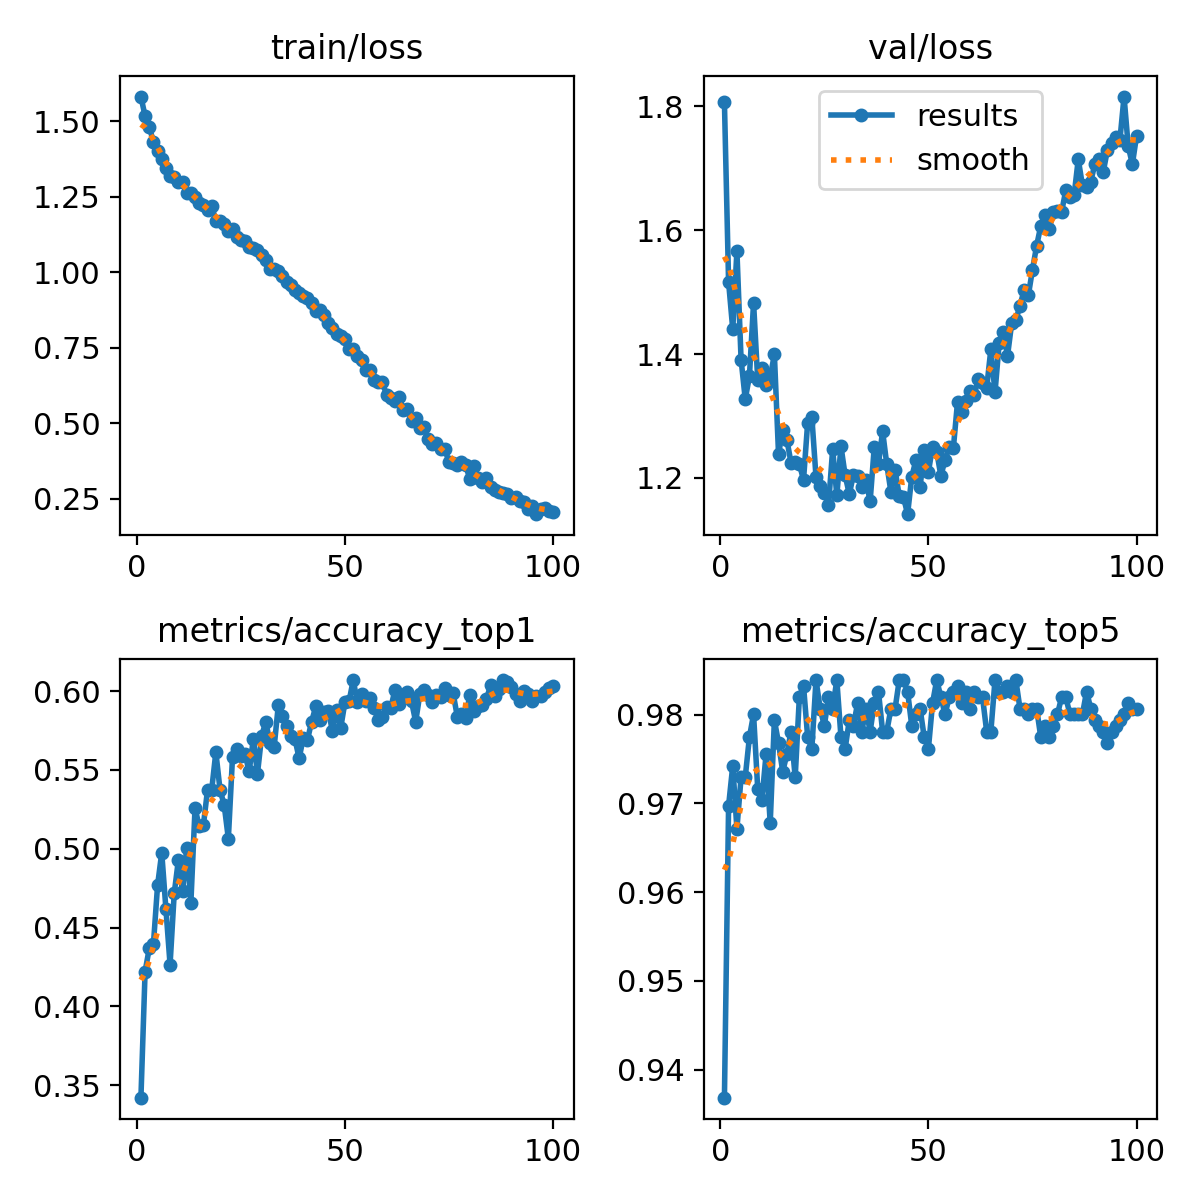

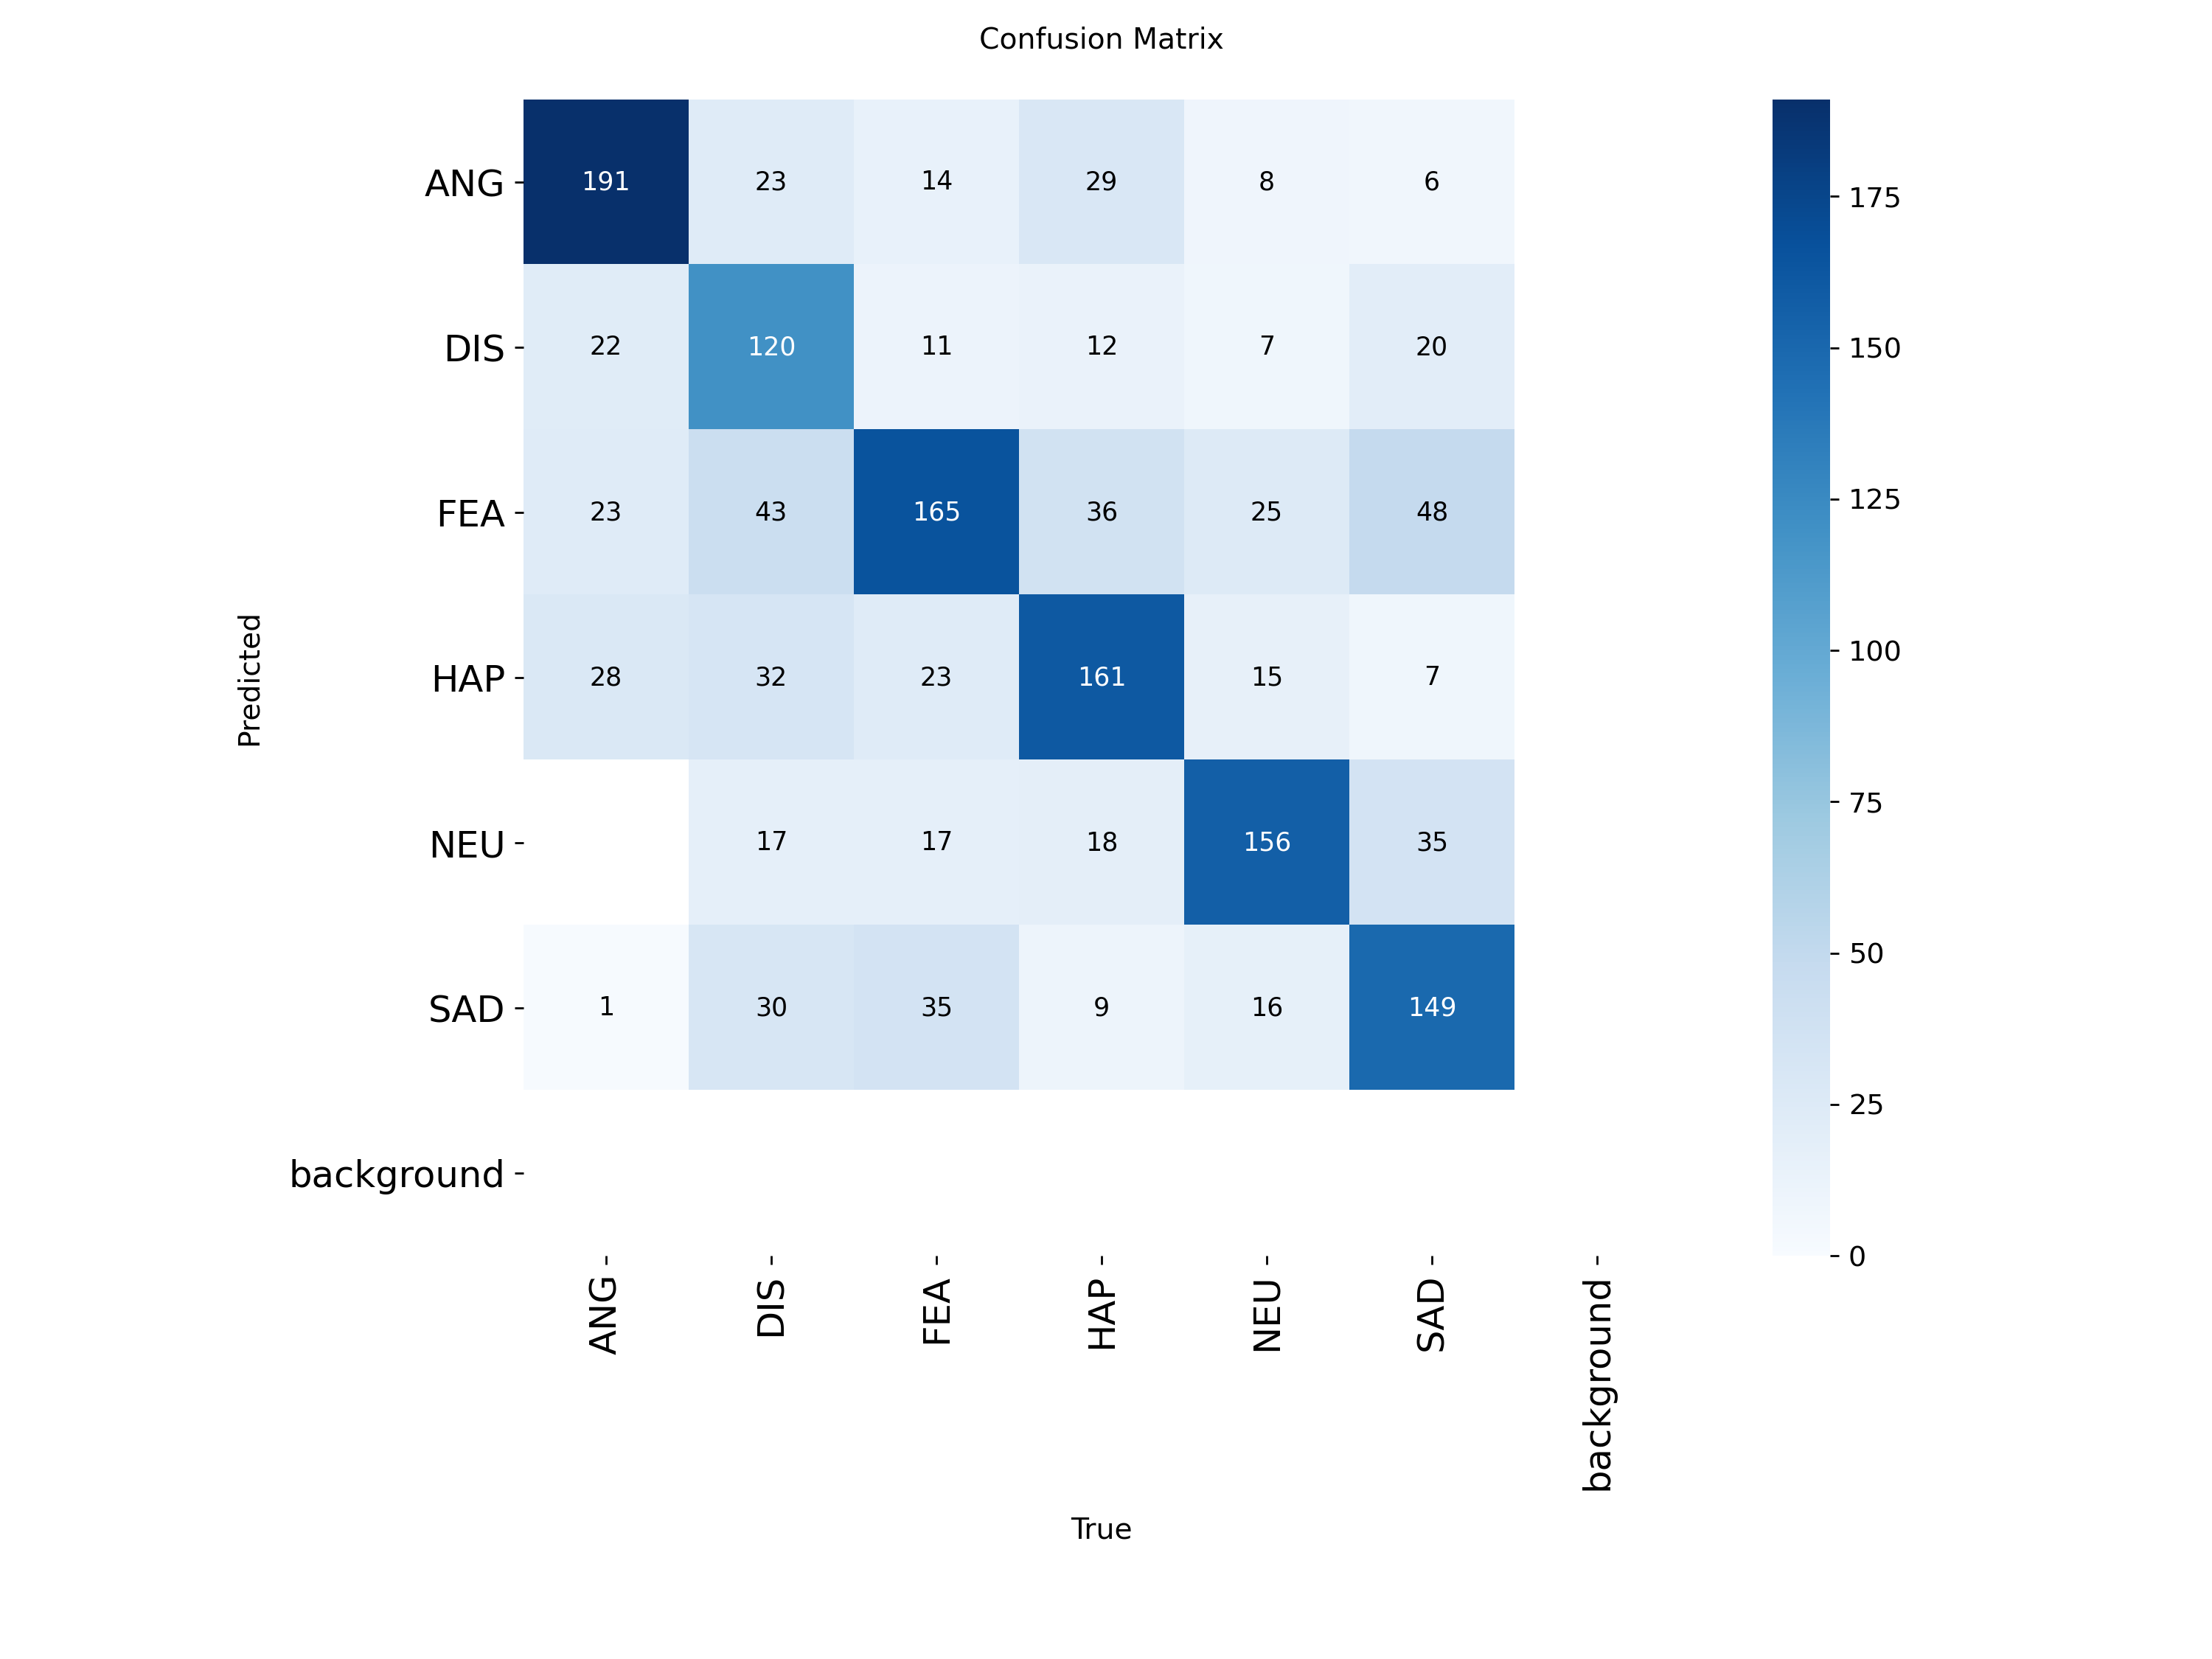

In [43]:
# Ultralytics renders its own summary plots into the run directory.
for fname in ("results.png", "confusion_matrix.png"):
    fpath = RUN_DIR / fname
    if fpath.exists():
        display(Image(filename=str(fpath)))
    else:
        print(f"(not found: {fpath})")

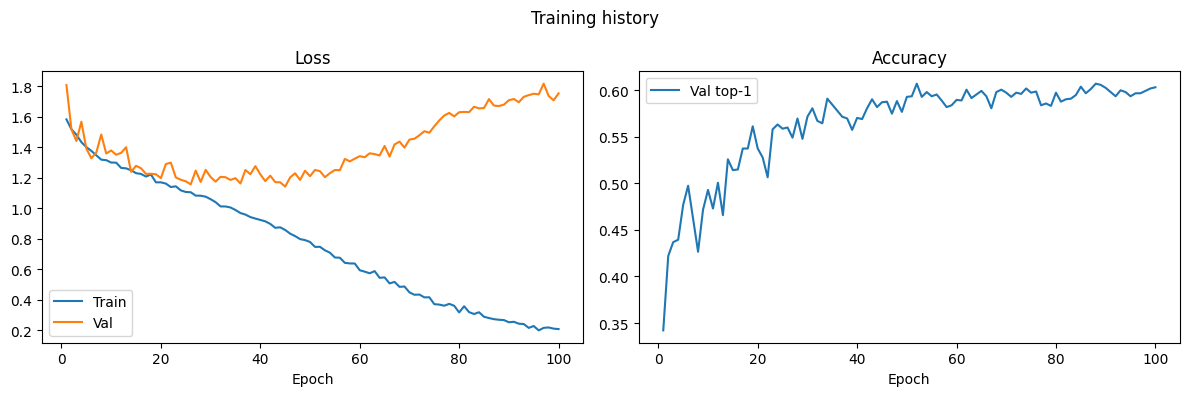

In [44]:
# Same loss/accuracy view as the template, parsed from results.csv.
csv_path = RUN_DIR / "results.csv"
df = pd.read_csv(csv_path)
df.columns = [c.strip() for c in df.columns]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(df["epoch"], df["train/loss"], label="Train")
if "val/loss" in df:
    ax1.plot(df["epoch"], df["val/loss"], label="Val")
ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.legend()

acc_col = "metrics/accuracy_top1"
if acc_col in df:
    ax2.plot(df["epoch"], df[acc_col], label="Val top-1")
ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend()

plt.suptitle("Training history")
plt.tight_layout()
plt.show()

## 7) Evaluation

In [45]:
# Ultralytics' own validation pass (top-1 / top-5 on the val=test split).
metrics = model.val(data=str(YOLO_DATASET_DIR), split="val", device=DEVICE)
print(f"top-1 accuracy: {metrics.top1:.4f}")
print(f"top-5 accuracy: {metrics.top5:.4f}")

Ultralytics 8.3.162 🚀 Python-3.13.5 torch-2.7.1+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Ti, 15840MiB)
YOLO11s-cls summary (fused): 47 layers, 5,441,814 parameters, 0 gradients, 12.0 GFLOPs
train: /home/velu/Documents/ISY-PM-2026-AIS07PT-Group31_PLACEHOLDER/SystemCode/data/training/yolo_dataset/train... found 5890 images in 6 classes ✅ 
val: /home/velu/Documents/ISY-PM-2026-AIS07PT-Group31_PLACEHOLDER/SystemCode/data/training/yolo_dataset/val... found 1552 images in 6 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 5230.4±2599.5 MB/s, size: 192.5 KB)


val: Scanning /home/velu/Documents/ISY-PM-2026-AIS07PT-Group31_PLACEHOLDER/SystemCode/data/training/yolo_dataset/val... 1552 images, 0 corrupt: 100%|██████████| 1552/1552 [00:00<?, ?it/s]
               classes   top1_acc   top5_acc: 100%|██████████| 49/49 [00:06<00:00,  7.18it/s]


                   all      0.607      0.984
Speed: 0.9ms preprocess, 2.2ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs/classify/yolo11s_cremad
top-1 accuracy: 0.6070
top-5 accuracy: 0.9839


### Per-class report

Manual pass over `data/test` to produce sklearn `classification_report` and confusion matrix

In [46]:
test_paths, all_labels = [], []
for idx, cls in enumerate(CLASS_NAMES):
    for p in sorted((TEST_DIR / cls).glob("*.png")):
        test_paths.append(str(p))
        all_labels.append(idx)

all_preds = []
BATCH = 64
for i in range(0, len(test_paths), BATCH):
    batch = test_paths[i:i + BATCH]
    for r in model.predict(batch, device=DEVICE, verbose=False):
        name = r.names[int(r.probs.top1)]
        all_preds.append(CLASS_NAMES.index(name))

print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

              precision    recall  f1-score   support

         ANG       0.70      0.72      0.71       265
         DIS       0.62      0.45      0.53       265
         FEA       0.49      0.62      0.55       265
         HAP       0.61      0.61      0.61       265
         NEU       0.64      0.69      0.66       227
         SAD       0.62      0.56      0.59       265

    accuracy                           0.61      1552
   macro avg       0.61      0.61      0.61      1552
weighted avg       0.61      0.61      0.61      1552



### Confusion matrix

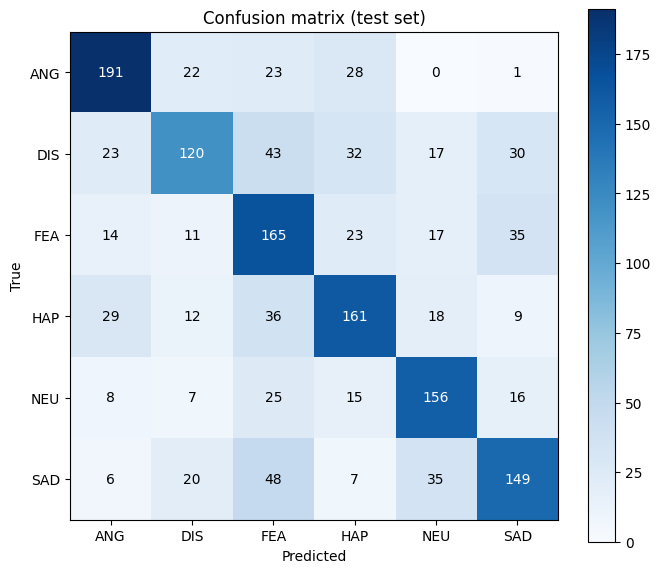

In [47]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
plt.colorbar(im, ax=ax)
ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES)
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix (test set)")

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.tight_layout()
plt.show()

## 8) Save the model

In [48]:
best = RUN_DIR / "weights" / "best.pt"
assert best.exists(), f"best.pt not found at {best}"
shutil.copy(best, MODEL_SAVE_PATH)
print(f"Model saved to {MODEL_SAVE_PATH.resolve()}")
print(f"(source: {best.resolve()})")

Model saved to /home/velu/Documents/ISY-PM-2026-AIS07PT-Group31_PLACEHOLDER/SystemCode/data/training/model_yolo.pt
(source: /home/velu/Documents/ISY-PM-2026-AIS07PT-Group31_PLACEHOLDER/SystemCode/data/training/runs/classify/yolo11s_cremad/weights/best.pt)
